<a href="https://colab.research.google.com/github/pimchayasupr-hash/CPE352-Anemia-Detection/blob/main/anemia_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas matplotlib seaborn scikit-learn imbalanced-learn kagglehub ipykernel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 49.9 MB/s eta 0:00:00


In [1]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ==========================================
# 0. ดาวน์โหลดและโหลดข้อมูล
# ==========================================
print("กำลังดาวน์โหลดข้อมูลจาก Kaggle...")
dataset_path = kagglehub.dataset_download("zara2099/iron-deficiency-anemia-clinical-dataset")
csv_file_path = os.path.join(dataset_path, "IDA_dataset.csv")

df = pd.read_csv(csv_file_path)
print("โหลดข้อมูลสำเร็จ!\n")

กำลังดาวน์โหลดข้อมูลจาก Kaggle...


100%|██████████| 7.78k/7.78k [00:00<00:00, 13.5MB/s]

Extracting files...
โหลดข้อมูลสำเร็จ!



In [2]:
# ==========================================
# 1. Data Ingestion & Profiling (การนำเข้าและสำรวจข้อมูลเบื้องต้น)
# ==========================================
print("--- 1. Data Loading: มิติของข้อมูล ---")
print(f"จำนวนแถว: {df.shape[0]} แถว")
print(f"จำนวนคอลัมน์: {df.shape[1]} คอลัมน์\n")

print("--- 2. Data Profiling: ชนิดของข้อมูล ---")
print(df.dtypes)

print("\n--- 3. สถิติเชิงพรรณนาเบื้องต้น ---")
display(df.describe())

--- 1. Data Loading: มิติของข้อมูล ---
จำนวนแถว: 1000 แถว
จำนวนคอลัมน์: 6 คอลัมน์

--- 2. Data Profiling: ชนิดของข้อมูล ---
Hemoglobin     float64
RDW            float64
MCV            float64
Age              int64
Gender          object
Anemia_Type     object
dtype: object

--- 3. สถิติเชิงพรรณนาเบื้องต้น ---


,Hemoglobin,RDW,MCV,Age
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,12.755300,14.145500,84.315000,48.402000
std,2.605548,1.675263,8.618099,18.032237
min,8.000000,11.500000,65.100000,18.000000
25%,10.500000,12.800000,78.875000,33.000000
50%,13.000000,14.000000,83.800000,48.000000
75%,15.025000,15.400000,90.800000,64.000000
max,17.000000,18.000000,100.000000,80.000000


/tmp/ipykernel_11337/2467626252.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Anemia_Type', data=df, palette='Set2')


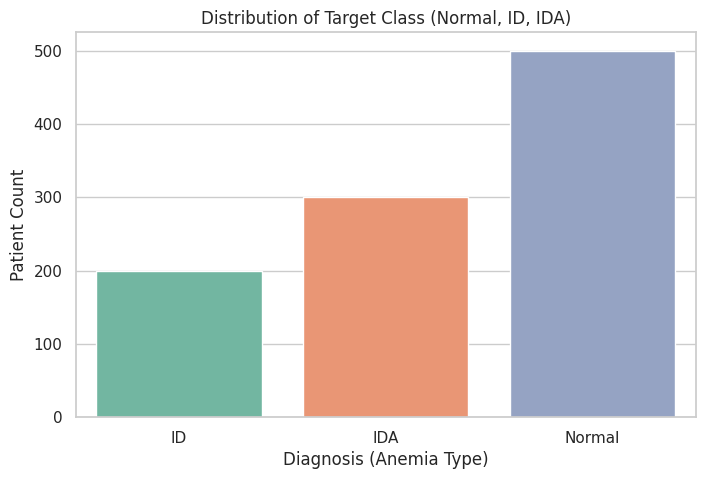

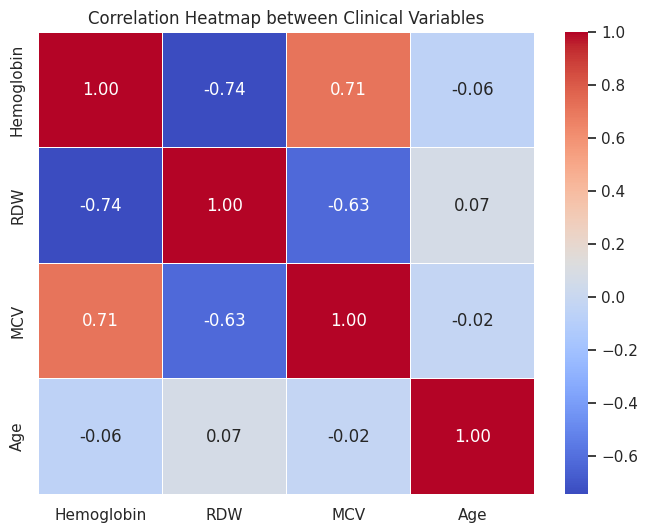

In [3]:
# ==========================================
# 4. Exploratory Data Analysis (EDA)
# ==========================================
sns.set_theme(style="whitegrid")

# 4.1 พล็อตกราฟดูการกระจายตัวของคลาสเป้าหมาย
plt.figure(figsize=(8, 5))
sns.countplot(x='Anemia_Type', data=df, palette='Set2')
plt.title('Distribution of Target Class (Normal, ID, IDA)')
plt.xlabel('Diagnosis (Anemia Type)')
plt.ylabel('Patient Count')
plt.show()

# 4.2 วิเคราะห์ความสัมพันธ์ระหว่างตัวแปรทางคลินิก (Correlation Heatmap)
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap between Clinical Variables')
plt.show()

In [4]:
# นำเข้าเครื่องมือที่จำเป็น
from sklearn.model_selection import train_test_split # สำหรับแบ่งชุดข้อมูล
from sklearn.preprocessing import LabelEncoder, StandardScaler # สำหรับแปลงข้อความเป็นเลข และปรับสเกลข้อมูล
from imblearn.over_sampling import SMOTE # สำหรับจัดการข้อมูลที่ไม่สมดุล (สร้างข้อมูลจำลอง)

# ==========================================
# 2. Data Preprocessing (การเตรียมข้อมูล)
# ==========================================
print("--- 2. Data Preprocessing ---")

# ตรวจสอบค่าว่าง (Missing Values)
# เหตุผล: โมเดล Machine Learning ส่วนใหญ่จะไม่สามารถทำงานได้ถ้ามีค่าว่าง (Null/NaN) ปนอยู่
print(f"จำนวนค่าว่างในชุดข้อมูล: \n{df.isnull().sum()}\n")
# (ข้อมูลชุดนี้ไม่มีค่าว่าง จึงข้ามการทำ Imputation หรือการเติมค่า/ตัดแถว ทิ้งไปได้เลย)

# Categorical Encoding: แปลงข้อมูลหมวดหมู่ (เพศ) ให้เป็นตัวเลข
# เหตุผล: คอมพิวเตอร์คำนวณได้เฉพาะตัวเลข ไม่เข้าใจคำว่า "Male" หรือ "Female"
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender']) # fit_transform จะจำแนกหมวดหมู่และเปลี่ยนเป็นเลข (เช่น 0, 1) อัตโนมัติ
print("แปลงข้อมูล 'Gender' เป็นตัวเลขเรียบร้อยแล้ว (เช่น Female=0, Male=1)")

# แยกตัวแปรต้น (X) และตัวแปรตาม/เป้าหมาย (y)
# X (Features) คือ "ข้อสอบ" หรือข้อมูลทั้งหมดที่โมเดลจะใช้ประกอบการตัดสินใจ จึงต้องตัดคอลัมน์เฉลยออก
X = df.drop('Anemia_Type', axis=1)
# y (Target) คือ "เฉลย" หรือสิ่งที่เราต้องการให้โมเดลทำนายออกมา
y = df['Anemia_Type']


--- 2. Data Preprocessing ---
จำนวนค่าว่างในชุดข้อมูล: 
Hemoglobin     0
RDW            0
MCV            0
Age            0
Gender         0
Anemia_Type    0
dtype: int64

แปลงข้อมูล 'Gender' เป็นตัวเลขเรียบร้อยแล้ว (เช่น Female=0, Male=1)


In [5]:
# ==========================================
# 3. Data Splitting & Resampling (แบ่งข้อมูลและจัดการสัดส่วน)
# ==========================================
print("\n--- 3. Data Splitting & Resampling ---")

# Train-Test Split: แบ่งข้อมูล Train 80% (ไว้สอนโมเดล) และ Test 20% (ไว้สอบวัดผลโมเดล)
# เหตุผลที่ใช้ stratify=y: เพื่อบังคับให้สัดส่วนของประเภทโลหิตจาง (y) ในชุด Train และ Test กระจายตัวเท่าๆ กัน ไม่ไปกระจุกที่กลุ่มใดกลุ่มหนึ่ง
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"ขนาดชุดข้อมูล Train ก่อนทำ SMOTE: {X_train.shape[0]} แถว")
print(f"ขนาดชุดข้อมูล Test: {X_test.shape[0]} แถว")

# Feature Scaling: ปรับสเกลข้อมูลให้ตัวเลขอยู่ในช่วงใกล้เคียงกันด้วย StandardScaler
# เหตุผล: ข้อมูลบางคอลัมน์เลขหลักสิบ (อายุ) บางคอลัมน์หลักแสน (จำนวนเม็ดเลือด) ต้องบีบให้สเกลเท่ากัน โมเดลจะได้ไม่ให้ความสำคัญกับเลขเยอะๆ มากเกินไป
scaler = StandardScaler()
# ชุด Train: ให้โมเดลเรียนรู้ค่าสถิติ (fit) และปรับสเกล (transform)
X_train_scaled = scaler.fit_transform(X_train)
# ชุด Test: ปรับสเกล (transform) อย่างเดียว **ห้าม fit ใหม่เด็ดขาด** เพื่อป้องกันไม่ให้โมเดลแอบเห็นข้อมูลเฉลย (ป้องกัน Data Leakage)
X_test_scaled = scaler.transform(X_test)
print("ปรับสเกลข้อมูล (Feature Scaling) ด้วย StandardScaler เรียบร้อยแล้ว")

# Handling Imbalanced Data: แก้ปัญหาข้อมูลคลาสไม่สมดุลด้วย SMOTE
# เหตุผล: ถ้าคนเป็นโรคนี้น้อยมาก โมเดลจะทายว่า "ไม่เป็นโรค" ตลอดเพราะง่ายกว่า SMOTE จะช่วย "สร้าง" ผู้ป่วยจำลอง (คณิตศาสตร์) ให้มีจำนวนเท่ากับคนปกติ
smote = SMOTE(random_state=42)
# **จุดสำคัญ:** ทำ SMOTE เฉพาะบนชุดข้อมูล Train เท่านั้น ห้ามทำกับชุด Test เพราะข้อมูลที่เราจะใช้ทดสอบ (สอบ) ต้องเป็นข้อมูลจริงตามธรรมชาติ
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"ขนาดชุดข้อมูล Train หลังทำ SMOTE: {X_train_resampled.shape[0]} แถว (ข้อมูลสมดุลแล้ว พร้อมนำไปเทรนโมเดล)")


--- 3. Data Splitting & Resampling ---
ขนาดชุดข้อมูล Train ก่อนทำ SMOTE: 800 แถว
ขนาดชุดข้อมูล Test: 200 แถว
ปรับสเกลข้อมูล (Feature Scaling) ด้วย StandardScaler เรียบร้อยแล้ว
ขนาดชุดข้อมูล Train หลังทำ SMOTE: 1200 แถว (ข้อมูลสมดุลแล้ว พร้อมนำไปเทรนโมเดล)


In [6]:
# นำเข้าเครื่องมือสำหรับสร้างโมเดล Random Forest และเครื่องมือวัดผลสอบ
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns # สำหรับวาดกราฟให้สวยงาม
import matplotlib.pyplot as plt # สำหรับจัดการหน้าต่างกราฟ
import pandas as pd # (เพิ่มเข้ามาให้โค้ดส่วน Feature Importance ทำงานได้สมบูรณ์)

# ==========================================
# 4. Modeling (การสร้างแบบจำลอง)
# ==========================================
print("--- 4. Modeling (Random Forest) ---")

# สร้างโมเดล Random Forest (เปรียบเสมือนการตั้ง "คณะกรรมการ" ที่ประกอบด้วยต้นไม้ตัดสินใจหลายๆ ต้น)
# n_estimators=100 : ให้มีต้นไม้ 100 ต้นมาช่วยกันโหวตผลลัพธ์ (ยิ่งเยอะยิ่งนิ่ง แต่นาน)
# class_weight='balanced' : เป็นการย้ำให้โมเดลให้ความสำคัญกับโรคที่พบได้ยาก (ถึงเราจะทำ SMOTE แล้ว การใส่ไว้ก็ช่วยดับเบิ้ลเช็คอีกชั้นนึงครับ)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# ฝึกสอนโมเดล (Train)
# ให้โมเดลเรียนรู้จาก "บทเรียน" (X_train_resampled) พร้อมกับดู "เฉลย" (y_train_resampled)
print("กำลังฝึกสอนโมเดล...")
rf_model.fit(X_train_resampled, y_train_resampled)
print("ฝึกสอนโมเดลเสร็จสมบูรณ์!\n")

# ให้โมเดลทำทดสอบ (Predict)
# นำ "ข้อสอบชุด Test" (X_test_scaled) ที่โมเดลไม่เคยเห็นมาก่อน มาให้โมเดลลองทำนายผล
y_pred = rf_model.predict(X_test_scaled)


--- 4. Modeling (Random Forest) ---
กำลังฝึกสอนโมเดล...
ฝึกสอนโมเดลเสร็จสมบูรณ์!



--- 5. Evaluation ---
ความแม่นยำของโมเดล (Accuracy Score): 100.00%

--- Classification Report ---
              precision    recall  f1-score   support

          ID       1.00      1.00      1.00        40
         IDA       1.00      1.00      1.00        60
      Normal       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3586 (\N{THAI CHARACTER KHO KHAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **

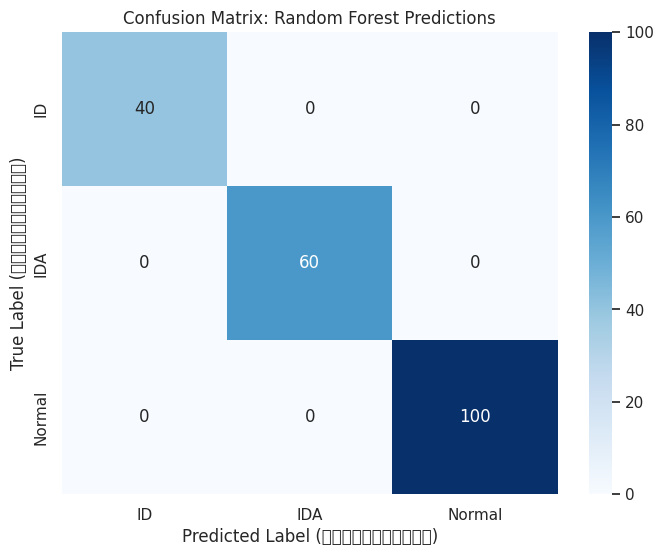

/tmp/ipykernel_11337/2825752744.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances, y=feature_importances.index, palette='magma')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Gly

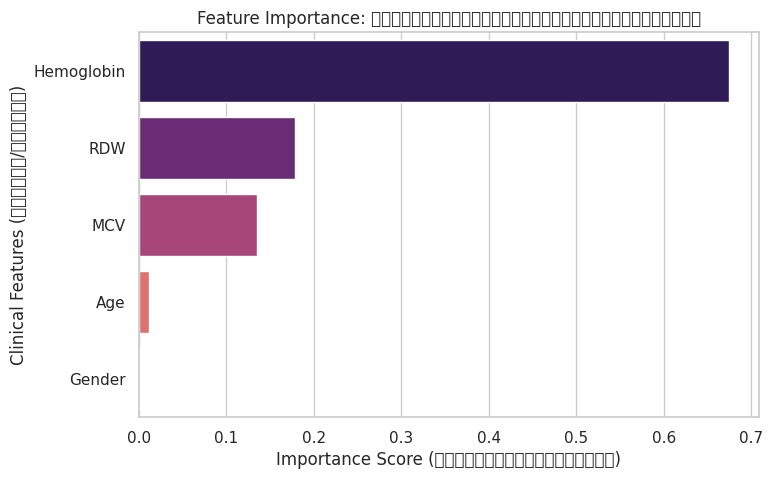

In [7]:
# ==========================================
# 5. Evaluation (การประเมินผลแบบจำลอง)
# ==========================================
print("--- 5. Evaluation ---")

# 5.1 ความแม่นยำรวม (Accuracy)
# เปรียบเทียบ "เฉลยจริง" (y_test) กับ "สิ่งที่โมเดลทาย" (y_pred) ว่าตรงกันกี่เปอร์เซ็นต์
accuracy = accuracy_score(y_test, y_pred)
print(f"ความแม่นยำของโมเดล (Accuracy Score): {accuracy * 100:.2f}%\n")

# 5.2 รายงานการประเมินผลแบบละเอียด (Classification Report)
# ดูแค่ความแม่นยำรวมไม่พอ ต้องดูแยกรายโรคด้วย (เหมือนดูเกรดแยกรายวิชา)
# จะบอกค่า Precision (ทายว่าเป็นโรคนี้ แล้วเป็นจริงแค่ไหน), Recall (คนเป็นโรคนี้จริง ถูกหาเจอแค่ไหน), F1-Score
print("--- Classification Report ---")
target_names = rf_model.classes_ # ดึงชื่อประเภทโลหิตจางออกมา
print(classification_report(y_test, y_pred))

# 5.3 กราฟ Confusion Matrix (ตารางแจกแจงการทายถูก/ผิด)
# กราฟนี้สำคัญมากสำหรับพรีเซนต์! มันจะบอกเลยว่าโมเดล "สับสน" โรคไหนกับโรคไหน
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
# ใช้ seaborn วาด Heatmap (สีเข้ม=ตัวเลขเยอะ)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.title('Confusion Matrix: Random Forest Predictions')
plt.xlabel('Predicted Label (โมเดลทายว่า)')
plt.ylabel('True Label (ของจริงเป็น)')
plt.show()

# 5.4 กราฟ Feature Importance (ความสำคัญของตัวแปร)
# โมเดล Random Forest สามารถบอกเราได้ว่า "ปัจจัยไหน (เช่น ค่าเลือดตัวไหน หรือ อายุ) มีผลต่อการตัดสินใจว่าเป็นโรคมากที่สุด"
# เป็นส่วนที่ใช้ "อธิบาย" ทางการแพทย์ได้ดีมากว่า AI ไม่ได้เดาสุ่ม แต่มองที่ค่าไหน
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
# วาดกราฟแท่งแนวนอน (Barplot) เรียงจากสำคัญมากไปน้อย
sns.barplot(x=feature_importances, y=feature_importances.index, palette='magma')
plt.title('Feature Importance: ปัจจัยที่มีผลต่อการทำนายมากที่สุด')
plt.xlabel('Importance Score (ยิ่งสูงยิ่งมีผลมาก)')
plt.ylabel('Clinical Features (ตัวแปร/ปัจจัย)')
plt.show()